# Fine-Tuning Qwen3-4B-Instruct for Financial Stock Forecasting on Amazon SageMaker

## Use Case Overview

This notebook fine-tunes **[Qwen3-4B-Instruct](https://huggingface.co/Qwen/Qwen3-4B-Instruct)** on the **[FinGPT/fingpt-forecaster-dow30-202305-202405](https://huggingface.co/datasets/FinGPT/fingpt-forecaster-dow30-202305-202405)** dataset — weekly stock-analysis records for Dow Jones 30 companies covering May 2023 to April 2024.

**Goal:** Teach the model to act as a financial analyst. Given a company's recent news and basic financial metrics, produce a structured analysis (positive developments, potential concerns) and predict the stock's directional movement for the upcoming week (e.g. *up by 3–4%*, *down by 1–2%*).

### Dataset schema

| Column | Description |
|--------|-------------|
| `prompt` | Analyst instruction with company news and financial metrics |
| `answer` | Structured response: developments, concerns, analysis, prediction |
| `period` | Date range (e.g. `2023-05-14 to 2023-05-21`) |
| `label` | Ground-truth movement (e.g. `up by 3-4%`) |
| `symbol` | Stock ticker (e.g. `AXP`, `AAPL`) |

### Training approach

- **QLoRA** — 4-bit NF4 quantisation of the base model + LoRA adapters on all linear layers (~1% trainable params).
- **SageMaker ModelTrainer** — managed training job on `ml.g5.2xlarge` (NVIDIA A10G, 24 GB VRAM).
- **Merge & save** — LoRA adapter is merged into the base model at the end; full model saved to S3 for PEFT-free deployment.

### Workflow
```
FinGPT Dataset (HuggingFace)
    │  load & format as chat messages
    ▼
Upload train/test splits → S3
    │
    ▼
SageMaker Training Job  (QLoRA + merge)
  Qwen3-4B-Instruct + LoRA  →  merged model → S3
    │
    ▼
SageMaker Real-time Endpoint  (LMI container)
    │
    ▼
Financial forecast inference
```

## Prerequisites

Install and pin exact versions of the required libraries. The same `scripts/requirements.txt` is used inside the SageMaker Training container, so keeping versions consistent between the notebook and the container avoids serialisation mismatches.

In [1]:
%pip install -r ./scripts/requirements.txt --upgrade

  Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.8 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 168.9 MB/s  0:00:00
  Created wheel for xtarfile: filename=xtarfile-0.2.1-py3-none-any.whl size=8150 sha256=8c3a1e5441ca74ee55b46f911239c80ca19755976104d2ca1e1d06dac326b5d5
  Stored in directory: /home/sagemaker-user/.cache/pip/wheels/0f/85/5c/cf54e1b5949f35f02a65eca4bb1be23e2a83f20d5ede6f89e7
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24988 sha256=901a4a788728e1efcd81d050024ecde191d1cec6ef5989f562e3005d28dfbf5c
  Stored in directory: /home/sagemaker-user/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d

## Restart the kernel

Several packages (`transformers`, `trl`) were upgraded above. A kernel restart ensures the current session picks up the new versions. Click **OK** when prompted.

In [2]:
from IPython import get_ipython
get_ipython().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

***

## Setup

Initialise a SageMaker `Session` to resolve the default S3 bucket and region. These values are used throughout the notebook to build S3 paths and submit training jobs. If you have a Managed MLflow Tracking Server, its ARN will be discovered automatically below.

In [5]:
import boto3
import shutil
from sagemaker.core.helper.session_helper import Session, get_execution_role
from sagemaker.core.config import load_sagemaker_config

sagemaker_session = Session()
s3_client = boto3.client('s3')

region = sagemaker_session.boto_session.region_name
bucket_name = sagemaker_session.default_bucket()
default_prefix = sagemaker_session.default_bucket_prefix
configs = load_sagemaker_config()

Look up the MLflow Tracking Server ARN by name (`genai-mlflow-tracker`). If the server does not exist, `mlflow_tracking_server_uri` is set to an empty string and experiment tracking is silently skipped — training still runs normally.

In [6]:
from botocore.exceptions import ClientError

try:
    response = boto3.client('sagemaker').describe_mlflow_tracking_server(
        TrackingServerName='genai-mlflow-tracker'
    )
    mlflow_tracking_server_uri = response['TrackingServerArn']
except ClientError:
    mlflow_tracking_server_uri = ""

if mlflow_tracking_server_uri == "":
    print("No MLflow Tracking Server Found, experiments will not be tracked.")
else:
    print(f"MLflow Tracking Server ARN: {mlflow_tracking_server_uri}")

MLflow Tracking Server ARN: arn:aws:sagemaker:us-east-1:590184118038:mlflow-tracking-server/genai-mlflow-tracker


Store the MLflow tracking URI and experiment name as environment variables. The training script reads these at launch and logs all metrics, parameters, and artefacts to the specified MLflow experiment.

In [7]:
import os

os.environ["mlflow_uri"] = mlflow_tracking_server_uri
os.environ["mlflow_experiment_name"] = "Qwen3-4B-Instruct-fingpt-forecaster-sft"

***

## Dataset: FinGPT Forecaster (DOW 30)

Load the **[fingpt-forecaster-dow30-202305-202405](https://huggingface.co/datasets/FinGPT/fingpt-forecaster-dow30-202305-202405)** dataset. The full training split has **1,230 examples**, one per company per week. Each `prompt` already embeds the analyst instruction along with the company's news and financials, so no additional context injection is needed.

`num_samples = 100` loads a subset for fast local iteration. Increase to `1230` or remove the slice to train on the full dataset.

In [8]:
from datasets import load_dataset
import pandas as pd

num_samples = 100

full_dataset = load_dataset("FinGPT/fingpt-forecaster-dow30-202305-202405", split=f"train[:{num_samples}]")

full_dataset[0]

README.md:   0%|          | 0.00/581 [00:00<?, ?B/s]

data/train-00000-of-00001-7c4c80aa07272d(…):   0%|          | 0.00/3.57M [00:00<?, ?B/s]

(…)-00000-of-00001-28531804b005ddc6.parquet:   0%|          | 0.00/925k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1230 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

{'prompt': "[INST]<<SYS>>\nYou are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week. Your answer format should be as follows:\n\n[Positive Developments]:\n1. ...\n\n[Potential Concerns]:\n1. ...\n\n[Prediction & Analysis]\nPrediction: ...\nAnalysis: ...\n\n<</SYS>>\n\n[Company Introduction]:\n\nAmerican Express Co is a leading entity in the Financial Services sector. Incorporated and publicly traded since 1977-05-18, the company has established its reputation as one of the key players in the market. As of today, American Express Co has a market capitalization of 168338.49 in USD, with 723.87 shares outstanding.\n\nAmerican Express Co operates primarily in the US, trading under the ticker AXP on the NEW YORK STOCK EXCHANGE, INC.. As a dominant force in the

In [34]:
sample = full_dataset[0]
Markdown(f"**Symbol:** {sample['symbol']}  |  **Period:** {sample['period']}  |  **Label:** {sample['label']}\n\n"
           f"**Prompt:**\n\n{sample['prompt']}\n\n---\n\n**Answer:**\n\n{sample['answer']}")

**Symbol:** AXP  |  **Period:** 2023-05-14 to 2023-05-21  |  **Label:** up by 3-4%

**Prompt:**

[INST]<<SYS>>
You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week. Your answer format should be as follows:

[Positive Developments]:
1. ...

[Potential Concerns]:
1. ...

[Prediction & Analysis]
Prediction: ...
Analysis: ...

<</SYS>>

[Company Introduction]:

American Express Co is a leading entity in the Financial Services sector. Incorporated and publicly traded since 1977-05-18, the company has established its reputation as one of the key players in the market. As of today, American Express Co has a market capitalization of 168338.49 in USD, with 723.87 shares outstanding.

American Express Co operates primarily in the US, trading under the ticker AXP on the NEW YORK STOCK EXCHANGE, INC.. As a dominant force in the Financial Services space, the company continues to innovate and drive progress within the industry.

From 2023-05-07 to 2023-05-14, AXP's stock price decreased from 150.55 to 145.90. News during this period are listed below:

[Headline]: Credit cards: issuers could use their own flexible friends
[Summary]: Concerns profitability has peaked following a strong 2022 are not baseless, but even so credit cards remain a lucrative business

[Headline]: Dow's nearly 175-point fall led by losses in American Express, Nike shares
[Summary]: Dragged down by losses for shares of American Express and Nike, the Dow Jones Industrial Average is trading down Wednesday afternoon. Shares of American...

[Headline]: Chase is opening its first U.S. airport lounge in Boston — here's how you can get in
[Summary]: The new Chase Sapphire Lounge at Boston Airport features complimentary food, drinks, rest pods, massage chairs and more. Here's how you can get in.

[Headline]: American Express Co. stock outperforms competitors despite losses on the day
[Summary]: Shares of American Express Co. sank 0.04% to $147.93 Friday, on what proved to be an all-around dismal trading session for the stock market, with the S&P 500...

[Headline]: How To Build A Dividend Portfolio With $25,000 Among May's Top 30 Stocks
[Summary]: An investment strategy that combines dividend income with dividend growth, brings several benefits for dividend income investors. Click here to read more.

Some recent basic financials of AXP, reported at 2023-03-31, are presented below:

[Basic Financials]:

assetTurnoverTTM: 0.2614
bookValue: 25992
cashRatio: 0.2944926548987087
currentRatio: 0.7185
ebitPerShare: 2.9126
eps: 2.4409
ev: 246452.85
fcfPerShareTTM: 20.2611
grossMargin: 0.624
longtermDebtTotalAsset: 0.1744
longtermDebtTotalCapital: 0.2169
longtermDebtTotalEquity: 1.5827
netDebtToTotalCapital: 0.6532
netDebtToTotalEquity: 4.7667
netMargin: 0.1189
operatingMargin: 0.1419
payoutRatioTTM: 0.2247
pb: 4.7152
peTTM: 16.9489
pretaxMargin: 0.1419
psTTM: 2.1201
quickRatio: 0.7185
receivablesTurnoverTTM: 1.0476
roaTTM: 0.0327
roeTTM: 0.2955
roicTTM: 0.0412
rotcTTM: 0.0515
salesPerShare: 20.5309
sgaToSale: 0.376
totalDebtToEquity: 6.2969
totalDebtToTotalAsset: 0.694
totalDebtToTotalCapital: 0.863
totalRatio: 1.1239

Based on all the information before 2023-05-14, let's first analyze the positive developments and potential concerns for AXP. Come up with 2-4 most important factors respectively and keep them concise. Most factors should be inferred from company related news. Then make your prediction of the AXP cryptocurrency price movement for next week (2023-05-14 to 2023-05-21). Provide a summary analysis to support your prediction.[/INST]

---

**Answer:**

[Positive Developments]:
1. Market Outperformance: Despite the recent fall, American Express' stock has outperformed competitors, implying strong fundamentals and investor confidence.
2. Strong Margins: The company has a strong gross margin of 62.4% and an even stronger operating margin of 14.19%, indicating good past profitability.
3. Solid Return on Equity (ROE): AXP’s ROE of 0.2955 suggests that it is effective at generating return on equity.

[Potential Concerns]:
1. High Debt Ratio: AXP's high total debt to equity ratio of 6.2969 means it relies heavily on debt to finance its assets which could be concerning in an adverse economic climate.
2. Decreasing Stock Price: Over the past week, AXP's stock price has fallen from 150.55 to 145.90. This suggests a downward trend may be in progress.
3. Market Losses: The recent losses in American Express and other Dow Jones stocks indicate a challenging market environment.

[Prediction & Analysis]:
Prediction: Up by 3-4%
Analysis: In spite of the potential concerns, the strong fundamentals of American Express offer promising prospects. Their strong gross and operating margins suggest that they have an effective cost strategy which motivates potential future investments and revenue generation. 

In addition, their ROE suggests they are capitalizing effectively on their equity. While the high debt ratio and falling stock price are potential concerns, these may offer buying opportunities for investors as they expect a rebound. 

Moreover, the stock has shown strength against other stocks, indicating that it remains a favored investment. Considering these factors, it is likely that the stock could see an uptrend in the coming week. A possible increase in the stock price of approximately 3-4% is anticipated. This outlook assumes stability in the overall market conditions and no significant negative financial news for the firm. 

However, investors should closely watch the company's debt levels and the broader market trends to ensure these do not adversely impact the stock's performance.

### Train / test split

Split the loaded subset 90% / 10% for training and evaluation. `seed=42` ensures the split is reproducible across runs. With `num_samples=100` this yields ~90 training examples and ~10 for validation loss tracking.

In [9]:
train_test_split_datasets = full_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = train_test_split_datasets["train"]
test_dataset = train_test_split_datasets["test"]

print(f"Number of train elements: {len(train_dataset)}")
print(f"Number of test elements: {len(test_dataset)}")

Number of train elements: 90
Number of test elements: 10


### Format dataset as chat messages

`SFTTrainer` requires each example to have a `messages` field in OpenAI chat format. `convert_to_messages` maps the FinGPT columns to three roles:

| Role | Source | Content |
|------|--------|---------|
| `system` | hardcoded | Stock analyst persona |
| `user` | `prompt` column | Company news + financials + request |
| `assistant` | `answer` column | Structured analysis + prediction |

All original columns (`prompt`, `answer`, `period`, `label`, `symbol`) are dropped after mapping.

In [10]:
SYSTEM_PROMPT = """You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week."""


# template dataset to add prompt to each sample
def convert_to_messages(sample, system_prompt=""):
    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": sample["prompt"]},
        {"role": "assistant", "content": sample["answer"]}
    ]

    sample["messages"] = messages
    
    return sample

Apply `convert_to_messages` to both train and test splits, then print a random example from each to confirm the chat format is correct before uploading to S3.

In [11]:
from random import randint

train_dataset = train_dataset.map(convert_to_messages, remove_columns=list(full_dataset.features), fn_kwargs={"system_prompt": SYSTEM_PROMPT})
test_dataset = test_dataset.map(convert_to_messages, remove_columns=list(full_dataset.features), fn_kwargs={"system_prompt": SYSTEM_PROMPT})

#grab a sample from the training and test sets
print(f"Train Sample:\n{train_dataset[randint(0, len(train_dataset)-1)]}\n\n")
print(f"Test Sample:\n{test_dataset[randint(0, len(test_dataset)-1)]}\n\n")

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Train Sample:
{'messages': [{'content': "You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week.", 'role': 'system'}, {'content': "[INST]<<SYS>>\nYou are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week. Your answer format should be as follows:\n\n[Positive Developments]:\n1. ...\n\n[Potential Concerns]:\n1. ...\n\n[Prediction & Analysis]\nPrediction: ...\nAnalysis: ...\n\n<</SYS>>\n\n[Company Introduction]:\n\nAmgen Inc is a leading entity in the Biotechnology sector. Incorporated and publicly traded since 1983-06-17, the

### Upload dataset to Amazon S3

Serialise the formatted datasets as JSON-lines files and upload them to the SageMaker default S3 bucket. The training job will mount these as input data channels:

- `train/dataset.json` → `/opt/ml/input/data/train/`
- `test/dataset.json` → `/opt/ml/input/data/test/`

Local copies are removed with `shutil.rmtree` after upload to keep the workspace clean.

In [12]:
# save train_dataset to s3 using our SageMaker session
if default_prefix:
    input_path = f'{default_prefix}/datasets/llm-fine-tuning-fingpt-forecaster'
else:
    input_path = f'datasets/llm-fine-tuning-fingpt-forecaster'

# Save datasets to s3
train_dataset.to_json("./data/train/dataset.json", orient="records")
test_dataset.to_json("./data/test/dataset.json", orient="records")

s3_client.upload_file("./data/train/dataset.json", bucket_name, f"{input_path}/train/dataset.json")
train_dataset_s3_path = f"s3://{bucket_name}/{input_path}/train/dataset.json"
s3_client.upload_file("./data/test/dataset.json", bucket_name, f"{input_path}/test/dataset.json")
test_dataset_s3_path = f"s3://{bucket_name}/{input_path}/test/dataset.json"

shutil.rmtree("./data")

print(f"Training data uploaded to:")
print(train_dataset_s3_path)
print(test_dataset_s3_path)

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Training data uploaded to:
s3://sagemaker-us-east-1-590184118038/datasets/llm-fine-tuning-fingpt-forecaster/train/dataset.json
s3://sagemaker-us-east-1-590184118038/datasets/llm-fine-tuning-fingpt-forecaster/test/dataset.json


### Visualise message-length distribution

Plot the character-length distribution of the formatted `messages` for train and validation sets. Use this to validate `max_seq_length` in `args.yaml` — set it above the 95th-percentile length to avoid truncating most examples while keeping GPU memory manageable.

[06/05/26 04:53:09] INFO     generated new fontManager                                         ]8;id=543328;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=199314;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py#1639\1639]8;;\

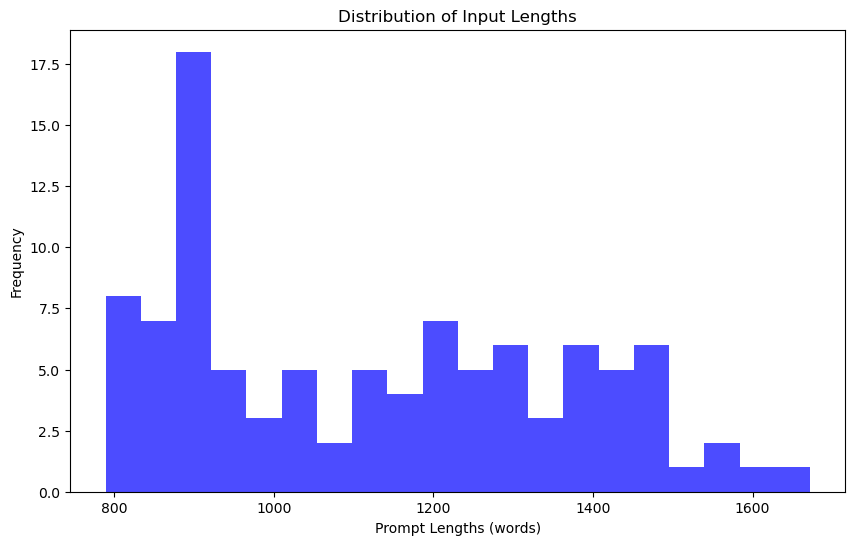

In [13]:
from utils import plot_length_distribution

plot_length_distribution(
    train_dataset=train_dataset,
    validation_dataset=test_dataset,
    bins=20,
    figsize=(10, 6)
)

***

## Model: Qwen3-4B-Instruct

**[Qwen3-4B-Instruct](https://huggingface.co/Qwen/Qwen3-4B-Instruct)** is a 4-billion parameter instruction-tuned model. At 4B parameters it fits on a single `ml.g5.2xlarge` GPU (24 GB VRAM) with 4-bit quantisation active.

`use_local_model = True` (default): uses the pre-downloaded copy in `../models/` and syncs it to S3, avoiding repeated HuggingFace downloads during training. Set to `False` to let the training container pull the model directly from the Hub.

In [14]:
model_id = "Qwen/Qwen3-4B-Instruct-2507"
model_id_filesafe = model_id.replace("/","_")

use_local_model = True #set to false for the training job to download from HF, otherwise True will download locally

If `use_local_model=True`, download the model weights to `../models/` using `snapshot_download` (skips files already present), then sync to S3 with `aws s3 sync`. The S3 URI is stored in `model_location` so `args.yaml` can reference it via `${model_location}`.

In [15]:
from huggingface_hub import snapshot_download
import os
import subprocess

if use_local_model:
    model_local_location = f"../models/{model_id_filesafe}"
    prefix = f"{default_prefix}/" if default_prefix else ""
    model_s3_destination = f"s3://{bucket_name}/{prefix}models/{model_id_filesafe}"
    
    print(f"Downloading model {model_id}")
    os.makedirs(model_local_location, exist_ok=True)
    snapshot_download(repo_id=model_id, local_dir=model_local_location)
    
    print("Beginning Model Upload...")
    subprocess.run(['aws', 's3', 'sync', model_local_location, model_s3_destination, 
                   '--exclude', '.cache/*', '--exclude', '.gitattributes'])
    
    print(f"Model uploaded to:\n{model_s3_destination}")
    os.environ["model_location"] = model_s3_destination
else:
    os.environ["model_location"] = model_id

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Beginning Model Upload...
Model uploaded to:
s3://sagemaker-us-east-1-590184118038/models/Qwen_Qwen3-4B-Instruct-2507


### Training hyperparameters (`args.yaml`)

Write the YAML config file consumed by `TrlParser` in the training script. Key parameters:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `max_seq_length` | 1500 | Covers ~95% of FinGPT prompt + answer lengths |
| `lora_r` / `lora_alpha` | 8 / 16 | Standard LoRA rank; balances capacity vs. VRAM |
| `per_device_train_batch_size` | 2 | Fits on ml.g5.2xlarge with gradient checkpointing |
| `gradient_accumulation_steps` | 2 | Effective batch size = 4 |
| `num_train_epochs` | 1 | Sufficient for domain adaptation on this dataset size |
| `fp16` | true | A10G supports FP16 natively; reduces memory vs. FP32 |
| `merge_weights` | true | LoRA merged into base at end — no PEFT needed at inference |

In [16]:
%%bash

cat > ./args.yaml <<EOF

# MLflow Config
mlflow_uri: "${mlflow_uri}"
mlflow_experiment_name: "${mlflow_experiment_name}"


model_id: "${model_location}"       # Hugging Face model id, or S3 location

# sagemaker specific parameters
output_dir: "/opt/ml/model"                       # path to where SageMaker will upload the model 
train_dataset_path: "/opt/ml/input/data/train/"   # path to where FSx saves train dataset
test_dataset_path: "/opt/ml/input/data/test/"     # path to where FSx saves test dataset
# training parameters
max_seq_length: 1500  #512 # 2048
lora_r: 8
lora_alpha: 16
lora_dropout: 0.1                 
learning_rate: 2e-4                    # learning rate scheduler
num_train_epochs: 1                    # number of training epochs
per_device_train_batch_size: 2         # batch size per device during training
per_device_eval_batch_size: 1          # batch size for evaluation
gradient_accumulation_steps: 2         # number of steps before performing a backward/update pass
gradient_checkpointing: true           # use gradient checkpointing
fp16: true
bf16: false                            # use bfloat16 precision
tf32: false                            # use tf32 precision

merge_weights: true                    # merge weights in the base model
EOF

Upload `args.yaml` to S3 as a separate input channel (`/opt/ml/input/data/config/`). The training script reads it with `TrlParser` at startup, so hyperparameters can be changed between runs without rebuilding the container image.

In [17]:
from sagemaker.core.s3 import S3Uploader

if default_prefix:
    input_path = f"s3://{bucket_name}/{default_prefix}/training_config/{model_id_filesafe}"
else:
    input_path = f"s3://{bucket_name}/training_config/{model_id_filesafe}"

# upload the model yaml file to s3
model_yaml = "args.yaml"
train_config_s3_path = S3Uploader.upload(local_path=model_yaml, desired_s3_uri=f"{input_path}/config")

print(f"Training config uploaded to:")
print(train_config_s3_path)

Training config uploaded to:
s3://sagemaker-us-east-1-590184118038/training_config/Qwen_Qwen3-4B-Instruct-2507/config/args.yaml


## Launch Fine-Tuning Job

Train with **QLoRA**: the base model is loaded in 4-bit NF4 quantisation (via `bitsandbytes`) and LoRA adapters are added to all linear layers. Only adapter parameters (~1% of total) are updated.

After training, `merge_weights: true` causes the script to merge the LoRA adapter back into the base model. The merged model is saved to `/opt/ml/model` and uploaded to S3 by SageMaker automatically.

#### Resolve the PyTorch training container URI

Retrieve the URI for the **PyTorch 2.6 training image** in the current region. This is the managed Docker container your `train.py` script will run inside.

In [18]:
instance_type = "ml.g5.2xlarge"

instance_type

'ml.g5.2xlarge'

In [19]:
from sagemaker.core import image_uris

image_uri = image_uris.retrieve(
    framework="pytorch",
    region=sagemaker_session.boto_session.region_name,
    version="2.6.0",
    instance_type=instance_type,
    image_scope="training"
)

image_uri

[06/05/26 04:54:23] INFO     Defaulting to only available Python version: py312                   ]8;id=136693;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=645591;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py#615\615]8;;\

'763104351884.dkr.ecr.us-east-1.amazonaws.com/pytorch-training:2.6.0-gpu-py312'

Configure the `ModelTrainer` for the SageMaker training job:

- **`SourceCode`** — points to `scripts/train.py` and `requirements.txt`; SageMaker zips and uploads the directory automatically.
- **`Compute`** — one `ml.g5.2xlarge` with a 1-hour warm-pool period to avoid instance cold-starts on re-runs.
- **Output path** — S3 location where SageMaker uploads the trained model artefacts after completion.

In [20]:
from sagemaker.train.model_trainer import ModelTrainer, InputData, Torchrun, StoppingCondition
from sagemaker.core.training.configs import Compute, SourceCode
from sagemaker.core.shapes import OutputDataConfig

# Define the script to be run
source_code = SourceCode(
    source_dir="./scripts",
    requirements="requirements.txt",
    entry_script="train.py",
)

# Define the compute
compute_configs = Compute(
    instance_type=instance_type,
    instance_count=1,
    keep_alive_period_in_seconds=3600,
    volume_size_in_gb=50
)

# define Training Job Name 
job_name = f"train-{model_id.split('/')[-1].replace('.', '-')}-sft-script"

# define OutputDataConfig path
if default_prefix:
    output_path = f"s3://{bucket_name}/{default_prefix}/{job_name}"
else:
    output_path = f"s3://{bucket_name}/{job_name}"

# Define the ModelTrainer
model_trainer = ModelTrainer(
    training_image=image_uri,
    source_code=source_code,
    base_job_name=job_name,
    compute=compute_configs,
    distributed=Torchrun(),
    stopping_condition=StoppingCondition(
        max_runtime_in_seconds=7200
    ),
    hyperparameters={
        "config": "/opt/ml/input/data/config/args.yaml"
    },
    output_data_config=OutputDataConfig(
        s3_output_path=output_path
    ),
    environment={
        "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True"
    }
)

[06/05/26 04:54:28] INFO     SageMaker session not provided. Using default Session.                  ]8;id=691569;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=513279;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py#61\61]8;;\

                    INFO     Role not provided. Using default role:                                  ]8;id=249242;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=279073;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py#75\75]8;;\
                             arn:aws:iam::590184118038:role/workshop-executionrole                                 

                    INFO     Training image URI:                                               ]8;id=328705;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=127075;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-east-1.amazonaws.com/pytorch-training:2.6                     
                             .0-gpu-py312                                                                          

Map the S3 dataset and config files to named input channels. The training script reads them at fixed container paths:

| Channel | S3 source | Container path |
|---------|-----------|----------------|
| `train` | `train/dataset.json` | `/opt/ml/input/data/train/` |
| `test` | `test/dataset.json` | `/opt/ml/input/data/test/` |
| `config` | `args.yaml` | `/opt/ml/input/data/config/` |

In [21]:
# Pass the input data
train_input = InputData(
    channel_name="train",
    data_source=train_dataset_s3_path,
)

test_input = InputData(
    channel_name="test",
    data_source=test_dataset_s3_path,
)

config_input = InputData(
    channel_name="config",
    data_source=train_config_s3_path,
)

# Check input channels configured
data = [train_input, test_input, config_input]
data

[InputData(channel_name='train', data_source='s3://sagemaker-us-east-1-590184118038/datasets/llm-fine-tuning-fingpt-forecaster/train/dataset.json', content_type=None),
 InputData(channel_name='test', data_source='s3://sagemaker-us-east-1-590184118038/datasets/llm-fine-tuning-fingpt-forecaster/test/dataset.json', content_type=None),
 InputData(channel_name='config', data_source='s3://sagemaker-us-east-1-590184118038/training_config/Qwen_Qwen3-4B-Instruct-2507/config/args.yaml', content_type=None)]

Submit the training job (`wait=True` streams CloudWatch logs in real time). SageMaker provisions the instance, pulls the container, runs `train.py`, and uploads the merged model to S3 on completion. Typical runtime for ~90 FinGPT examples on `ml.g5.2xlarge`: **5–10 minutes**.

In [22]:
# starting the train job with our uploaded datasets as input
model_trainer.train(input_data_config=data, wait=True)

[06/05/26 04:54:31] INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=291355;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=639561;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/telemetry/telemetry_logging.py#110\110]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


[06/05/26 04:54:32] INFO     Creating training_job resource.                                     ]8;id=795409;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=205877;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#31116\31116]8;;\

                    WARNING  No region provided. Using default region.                                 ]8;id=278457;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=81209;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py#361\361]8;;\

                    INFO     Runs on sagemaker prod, region:us-east-1                                  ]8;id=405660;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=596537;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py#375\375]8;;\

...

                    INFO     train-Qwen3-4B-Instruct-2507-sft-script-20260605045431/algo-1-17806 ]8;id=467322;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=449949;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#31439\31439]8;;\
                             35336:                                                                                
                             :[W605 05:04:08.847096504 ProcessGroupNCCL.cpp:1496] Warning:                         
                             WARNING: destroy_process_group() was not called before program                        
                             exit, which can leak resources. For more info, please see                             
                             https://pytorch.org/docs/stable/distributed.html#shutdown (function                   
                             operator())                                                                           

                    INFO     train-Qwen3-4B-Instruct-2507-sft-script-20260605045431/algo-1-17806 ]8;id=827741;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=26918;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#31439\31439]8;;\
                             35336:                                                                                
                             ip-10-0-185-133:95:199 [0] NCCL INFO comm 0x562ca6e69490 rank 0                       
                             nranks 1 cudaDev 0 busId 1e0 - Abort COMPLETE                                         

                    INFO     train-Qwen3-4B-Instruct-2507-sft-script-20260605045431/algo-1-17806 ]8;id=685283;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=476913;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#31439\31439]8;;\
                             35336:                                                                                
                             Training Container Execution Completed                                                

                    INFO     train-Qwen3-4B-Instruct-2507-sft-script-20260605045431/algo-1-17806 ]8;id=921255;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=348066;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#31439\31439]8;;\
                             35336:                                                                                
                             ++ echo 'Training Container Execution Completed'                                      

[06/05/26 05:06:16] INFO     Final Resource Status: Completed                                    ]8;id=425025;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=408795;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#31442\31442]8;;\

***

# Model Deployment

Deploy the fine-tuned merged model to a SageMaker **Real-time Endpoint** using the [Large Model Inference (LMI)](https://docs.aws.amazon.com/sagemaker/latest/dg/large-model-inference.html) DJL container.

LMI handles continuous batching, optimised CUDA kernels (vLLM / TRT-LLM), and the OpenAI-compatible request format. No PEFT library is required at inference because the adapter was merged at training time.

## Load fine-tuned model artefacts

Retrieve the most recently completed training job matching the job-name prefix. This avoids hardcoding a specific job name when training is re-run multiple times.

In [23]:
import sys
from utils import get_last_job_name

job_prefix = f"train-{model_id.split('/')[-1].replace('.', '-')}-sft-script"

job_name = get_last_job_name(job_prefix)

job_name

'train-Qwen3-4B-Instruct-2507-sft-script-20260605045431'

#### Endpoint configuration

- **`instance_type`** — `ml.g5.2xlarge`: same GPU family as training; sufficient for 4B-parameter FP16 inference.
- **`health_check_timeout`** — 700 s: the LMI container needs extra time to download and initialise the model weights on first start.

In [24]:
instance_count = 1
instance_type = "ml.g5.2xlarge"
health_check_timeout = 700

Use the AWS **Deep Java Library (DJL) LMI container** for inference. This image ships optimised backends (vLLM / TensorRT-LLM), handles model sharding, continuous batching, and an OpenAI-compatible `/invocations` request format out of the box.

In [25]:
inference_image_uri = f"763104351884.dkr.ecr.{region}.amazonaws.com/djl-inference:0.33.0-lmi15.0.0-cu128"
print(f"using image to host: {inference_image_uri}")

using image to host: 763104351884.dkr.ecr.us-east-1.amazonaws.com/djl-inference:0.33.0-lmi15.0.0-cu128


Create a SageMaker **Model** resource pointing to the merged model tarball in S3, then define an **EndpointConfig** specifying the instance type and the LMI container. The IAM execution role grants the endpoint permission to read model artefacts from S3.

In [26]:
import json
from sagemaker.core.resources import Model, Endpoint, EndpointConfig
from sagemaker.core.shapes import ContainerDefinition, ProductionVariant

role = get_execution_role(sagemaker_session, use_default=True)

if default_prefix:
    model_data=f"s3://{bucket_name}/{default_prefix}/{job_prefix}/{job_name}/output/model.tar.gz"
else:
    model_data=f"s3://{bucket_name}/{job_prefix}/{job_name}/output/model.tar.gz"

deploy_model_name = f"Qwen3-4B-sft-{job_name[-8:]}"

core_model = Model.create(
    model_name=deploy_model_name,
    execution_role_arn=role,
    primary_container=ContainerDefinition(
        image=inference_image_uri,
        model_data_url=model_data,
        environment={
            'HF_MODEL_ID': "/opt/ml/model",
            'OPTION_TRUST_REMOTE_CODE': 'true',
            'OPTION_ROLLING_BATCH': "vllm",
            'OPTION_DTYPE': 'bf16',
            'OPTION_QUANTIZE': 'fp8',
            'OPTION_TENSOR_PARALLEL_DEGREE': 'max',
            'OPTION_MAX_ROLLING_BATCH_SIZE': '32',
            'OPTION_MODEL_LOADING_TIMEOUT': '3600',
            'OPTION_MAX_MODEL_LEN': '4096'
        }
    ),
)

[06/05/26 05:11:33] INFO     Creating model resource.                                            ]8;id=192419;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=490227;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#20477\20477]8;;\

Create and deploy the endpoint. `_wait_until` polls SageMaker until the endpoint reaches `InService` status. Allow **5–8 minutes** for the LMI container to start, download model weights, and pass health checks.

In [27]:
from sagemaker.core.common_utils import name_from_base
from sagemaker.core.helper.session_helper import _wait_until, _deploy_done

endpoint_name = f"{model_id.split('/')[-1].replace('.', '-')}-sft"
TUNED_ENDPOINT_NAME = name_from_base(endpoint_name)

EndpointConfig.create(
    endpoint_config_name=TUNED_ENDPOINT_NAME,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=deploy_model_name,
            initial_instance_count=instance_count,
            instance_type=instance_type,
            container_startup_health_check_timeout_in_seconds=health_check_timeout,
            model_data_download_timeout_in_seconds=3600,
        )
    ],
)

core_endpoint = Endpoint.create(
    endpoint_name=TUNED_ENDPOINT_NAME,
    endpoint_config_name=TUNED_ENDPOINT_NAME,
)

_wait_until(lambda: _deploy_done(sagemaker_session.sagemaker_client, TUNED_ENDPOINT_NAME), poll=30)
core_endpoint = Endpoint.get(endpoint_name=TUNED_ENDPOINT_NAME)
print(f"Endpoint status: {core_endpoint.endpoint_status}")

[06/05/26 05:11:34] INFO     Creating endpoint_config resource.                                  ]8;id=190990;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=412037;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#11069\11069]8;;\

[06/05/26 05:11:35] INFO     Creating endpoint resource.                                         ]8;id=887676;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=2281;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#10228\10228]8;;\

----------------------!Endpoint status: InService


#### Run a test prediction

Send a financial forecasting prompt to the deployed endpoint. The prompt mirrors the FinGPT training format — an analyst instruction with company news and financials.

The model should return:
1. **Positive Developments** — bullish signals
2. **Potential Concerns** — bearish / risk signals
3. **Prediction** — directional movement for the upcoming week

Adjust `temperature` (lower = more deterministic) and `max_new_tokens` to control response diversity and length.

In [28]:
SYSTEM_PROMPT = f"""You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week."""

USER_PROMPT = "[Instruction]\nAnalyze the weekly stock price movement for Apple (AAPL) based on recent news and financials.\n[Input]\nRecent news: Apple reported strong quarterly earnings, beating analyst estimates. New product launches announced.\n"

messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": USER_PROMPT},
]

messages

[{'role': 'system',
  'content': "You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week."},
 {'role': 'user',
  'content': '[Instruction]\nAnalyze the weekly stock price movement for Apple (AAPL) based on recent news and financials.\n[Input]\nRecent news: Apple reported strong quarterly earnings, beating analyst estimates. New product launches announced.\n'}]

In [29]:
payload = json.dumps({
	"messages": messages,
    "parameters": {
        "temperature": 0.2,
        "top_p": 0.9,
        "return_full_text": False,
        "max_new_tokens": 1024
    }
})

response = core_endpoint.invoke(
    body=payload,
    content_type="application/json",
    accept="application/json",
)

result = json.loads(response.body.read().decode("utf-8"))
result["choices"][0]["message"]["content"]

"[Analysis and Prediction]\n\nPositive Developments:\n1. Strong Quarterly Earnings: Apple reported strong quarterly earnings, surpassing analyst estimates. This indicates robust financial performance and effective management of the company's operations.\n2. New Product Launches: Apple announced new product launches, signaling innovation and continued investment in product development. These launches can drive future revenue growth and enhance market competitiveness.\n\nPotential Concerns:\n1. Market Saturation: While Apple's product launches are promising, the market may be experiencing saturation in certain product categories. This could limit the potential impact of new products on overall sales.\n2. Intense Competition: Apple faces increasing competition from other tech giants and emerging players. These competitors may offer similar or improved products, potentially impacting Apple's market share and pricing power.\n\nPrediction:\nBased on the positive developments and recent news,

In [31]:
from IPython.display import Markdown
Markdown(result["choices"][0]["message"]["content"])

[Analysis and Prediction]

Positive Developments:
1. Strong Quarterly Earnings: Apple reported strong quarterly earnings, surpassing analyst estimates. This indicates robust financial performance and effective management of the company's operations.
2. New Product Launches: Apple announced new product launches, signaling innovation and continued investment in product development. These launches can drive future revenue growth and enhance market competitiveness.

Potential Concerns:
1. Market Saturation: While Apple's product launches are promising, the market may be experiencing saturation in certain product categories. This could limit the potential impact of new products on overall sales.
2. Intense Competition: Apple faces increasing competition from other tech giants and emerging players. These competitors may offer similar or improved products, potentially impacting Apple's market share and pricing power.

Prediction:
Based on the positive developments and recent news, Apple's stock price is likely to increase for the upcoming week. The strong quarterly earnings and new product launches indicate positive momentum for the company. However, market saturation and intense competition remain potential concerns that could influence future performance. Overall, Apple's stock is expected to move upwards due to its strong financials and innovative product offerings.

### Save endpoint name

Persist `TUNED_ENDPOINT_NAME` with `%store` so downstream notebooks (evaluation, benchmarking, RAG pipelines) can reference the live endpoint without manually copying the name.

In [30]:
%store TUNED_ENDPOINT_NAME

Stored 'TUNED_ENDPOINT_NAME' (str)
